In [1]:
#Install dependencies
!pip install scikit-learn

import pandas as pd
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice
from pandas.plotting import parallel_coordinates
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
#Set seed
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

In [3]:
fires = pd.read_csv('fire_climate_dataset.csv')
fires = pd.DataFrame(fires)

In [4]:
fires.columns

Index(['datecurrent', 'fireyear', 'incidentname', 'perimeterdatetime',
       'gisacres', 'lat', 'lon', 'geometry', 'index_right', 'NAME',
       'fire_date', 'year', 'month', 'lon_adj', 'date', 'temp_month',
       'precip_month'],
      dtype='str')

In [5]:
#narrow df to numeric values only
fires_cluster = fires[['fireyear','lat','lon','month','temp_month','precip_month','gisacres']]

In [6]:
print(fires_cluster.head())

   fireyear        lat         lon  month  temp_month  precip_month   gisacres
0      2005  39.262110 -108.705537      7   80.060176      0.001951  17.511509
1      2017  39.246299 -108.700311      5   61.228730      0.035027   0.707301
2      2016  39.261301 -108.714669      7   78.095381      0.015024   0.123598
3      2015  40.748563 -107.756655      9   61.494160      0.027260   7.225905
4      2017  39.208467 -108.654979      5   61.228730      0.035027  28.773811


In [7]:
fires_cluster.to_csv('fires_cluster')

In [8]:
features = ['fireyear','lat','lon','month','temp_month','precip_month','gisacres']

In [9]:
#Scale - gisacres is very large compared to other features
scaler = StandardScaler()
X = scaler.fit_transform(fires_cluster)

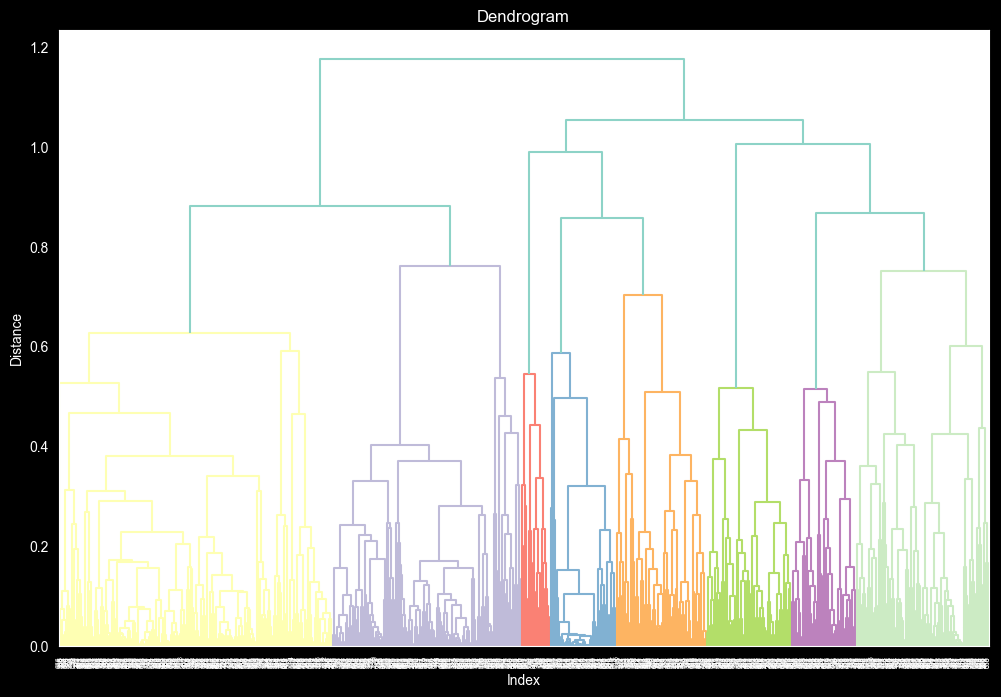

In [10]:
#Create dendrogram (hierarchical clustering)
Z = linkage(X, method ='average',metric='cosine')

plt.figure(figsize=(12, 8))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()

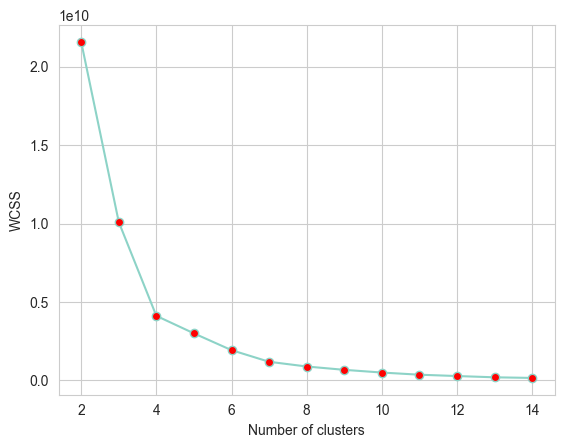

In [11]:
#Use elbow method to check appropriate k
inertia_score = []

for i in range(2,15):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(fires_cluster)
    inertia_score.append(km.inertia_)

sns.set_style('whitegrid')
plt.plot(range(2,15),inertia_score,marker='o',markerfacecolor='r')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

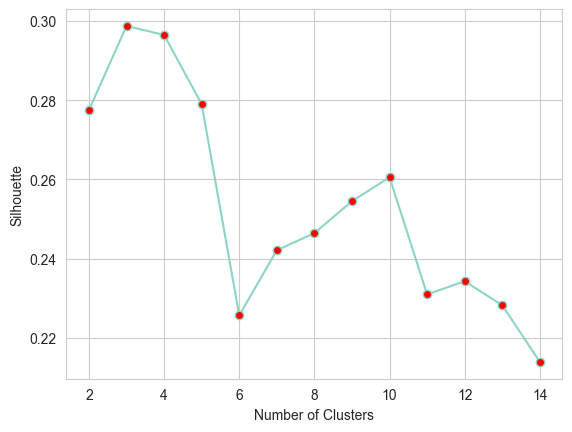

In [12]:
#assess silhouette score for optimal k
scores = []

for k in range(2,15):
    model = KMeans(n_clusters = k,random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.plot(range(2,15),scores,marker='o',markerfacecolor='r')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette')
plt.show()

In [13]:
#Fit kmeans to 4 clusters
KM = KMeans(n_clusters = 4)
model = KM.fit(X)
centers = model.cluster_centers_

In [14]:
#produce parallel plots using centroids
def pd_centers(featuresUsed, centers):
    colNames = list(featuresUsed)
    colNames.append('prediction')
    Z = [np.append(A, index) for index, A in enumerate(centers)]
    P = pd.DataFrame(Z, columns = colNames)
    P['prediction'] = P['prediction'].astype(int)
    return P

def parallel_plots(data):
    my_colors = list(islice(cycle(['b', 'r', 'g', 'y', 'k']), None, len(data)))
    plt.figure(figsize=(15,8)).gca().axes.set_ylim([-1.5, +2])
    parallel_coordinates(data, 'prediction', color = my_colors, marker = 'o')

P = pd_centers(features, centers)

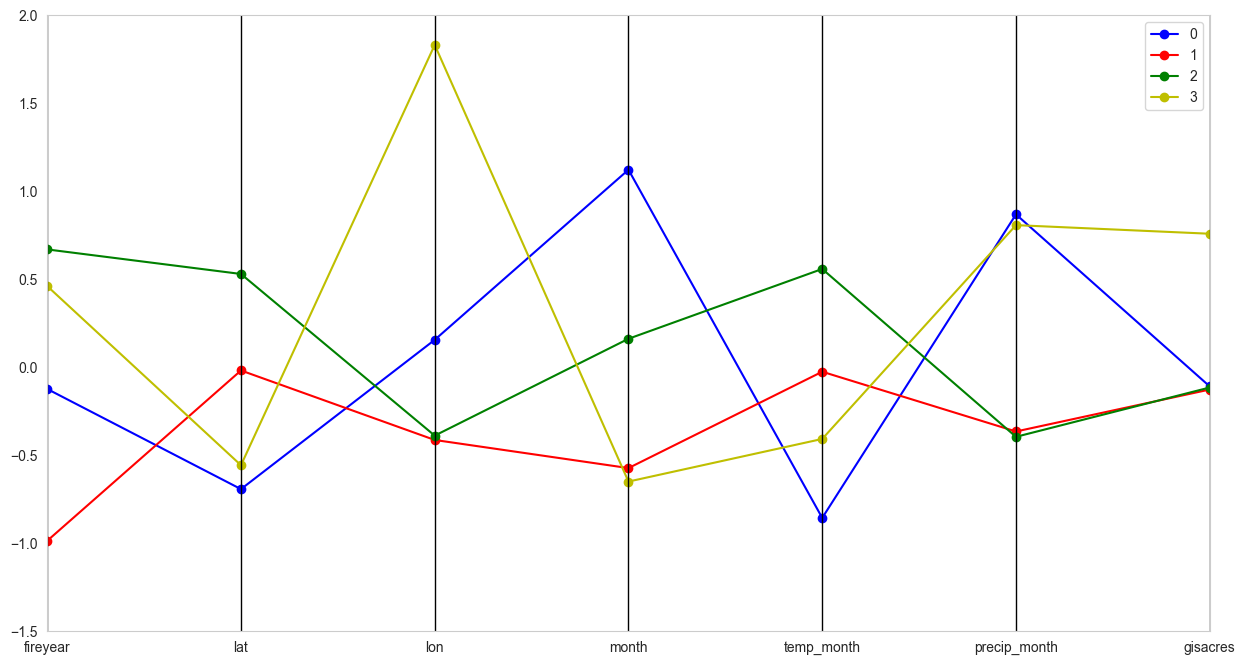

In [15]:
parallel_plots(P)

In [16]:
centers_original = scaler.inverse_transform(model.cluster_centers_)

centers_fires = pd.DataFrame(
    centers_original,
    columns = fires_cluster.columns,
)

print(centers_fires.to_string())

      fireyear        lat         lon     month  temp_month  precip_month     gisacres
0  2009.196429  38.691216 -107.522701  9.482143   46.247716      0.066593   962.580402
1  2004.206294  39.407903 -108.218857  5.821678   60.005935      0.026944   812.314487
2  2013.783562  39.990674 -108.188782  7.408219   69.676744      0.025969   909.981392
3  2012.578125  38.835620 -105.472372  5.656250   53.678919      0.064628  8349.356996


In [17]:
centers_fires.to_csv('centers_fires.csv')

In [18]:
fires_cluster["cluster"] = model.labels_
fires_cluster["cluster"].value_counts().sort_index()

cluster
0    169
1    283
2    367
3    128
Name: count, dtype: int64

In [19]:
cluster_summary = fires_cluster.groupby("cluster").agg({
    "gisacres": ["count", "mean", "median"],
    "temp_month": "mean",
    "precip_month": "mean",
    "month": "mean",
    "lat": "mean",
    "lon": "mean"
}).round(2)
print(cluster_summary.to_string())

        gisacres                  temp_month precip_month month    lat     lon
           count     mean  median       mean         mean  mean   mean    mean
cluster                                                                       
0            169   957.02   88.18      46.31         0.07  9.48  38.69 -107.53
1            283   820.32   65.36      59.92         0.03  5.80  39.41 -108.21
2            367   905.43   55.62      69.70         0.03  7.41  39.98 -108.19
3            128  8349.36  322.66      53.68         0.06  5.66  38.84 -105.47


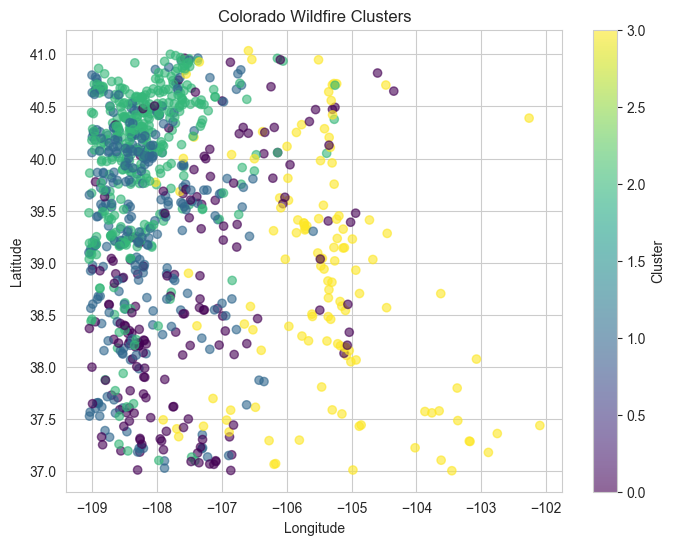

In [20]:
#produce plot to show clusters based on location in Colorado
plt.figure(figsize=(8,6))

plt.scatter(
    fires_cluster["lon"],
    fires_cluster["lat"],
    c=fires_cluster["cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Colorado Wildfire Clusters")
plt.colorbar(label="Cluster")
plt.show()